# 6. Przygotowanie danych do modelowania

W kolejnym etapie projektu przeprowadzono proces przygotowania danych do modelowania predykcyjnego. Celem tego etapu było ograniczenie wpływu problemów jakościowych występujących w danych surowych oraz przygotowanie zmiennych do wykorzystania w modelach uczenia maszynowego.

W ramach przygotowania danych wykonano między innymi:

- analizę oraz obsługę brakujących wartości,
- identyfikację i ograniczenie wpływu wartości odstających,
- transformację wybranych zmiennych numerycznych,
- przygotowanie danych tekstowych do dalszej analizy NLP,
- przygotowanie zbioru danych do procesu modelowania.

In [1]:
# ============================================================
# Import bibliotek
# ============================================================

import pandas as pd
import numpy as np
import joblib

from scipy.sparse import save_npz
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split


In [2]:
# ============================================================
# Wczytanie danych
# ============================================================

df = pd.read_csv("../data/raw/new_york_real_estate_2026_final.csv")

print("Rozmiar zbioru danych:", df.shape)

df.head()

Rozmiar zbioru danych: (8273, 11)


,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
0,single_family,NaN,No description provided.,325000.0,1252.0,2.0,3.0,2.0,2.0,2.0,1.0
1,single_family,NaN,Shortsale.,308000.0,NaN,NaN,4.0,4.0,4.0,4.0,NaN
2,multi_family,NaN,Discover an exceptional investment opportunity...,799999.0,NaN,NaN,11.0,6.0,7.0,7.0,1.0
3,single_family,NaN,Classic Cape Cod with 4 bedrooms and 2 full ba...,189900.0,1400.0,3.0,4.0,2.0,2.0,2.0,2.0
4,single_family,NaN,"Spacious 4-bedroom, 2.5-bath two-story home of...",204900.0,2074.0,2.0,4.0,2.0,2.0,2.0,2.0


In [3]:
# ============================================================
# Utworzenie kopii roboczej danych
# ============================================================

df_model = df.copy()

## 6.1. Analiza i obsługa brakujących danych

W tej części przeprowadzono analizę brakujących wartości występujących w zbiorze danych oraz oceniono ich zależność od typu nieruchomości. Na podstawie uzyskanych wyników podjęto decyzje dotyczące dalszego filtrowania i przygotowania danych do modelowania.

In [4]:
# ============================================================
# Analiza brakujących danych
# ============================================================

missing_summary = pd.DataFrame({
    "missing_count": df_model.isnull().sum(),
    "missing_percent": (
        df_model.isnull().mean() * 100
    )
})

missing_summary = (
    missing_summary
    .sort_values(
        by="missing_percent",
        ascending=False
    )
    .round(2)
)

missing_summary

,missing_count,missing_percent
sub_type,6375,77.06
garage,4211,50.90
stories,4176,50.48
sqft,1106,13.37
baths_full,427,5.16
baths_full_calc,418,5.05
baths,391,4.73
beds,340,4.11
type,0,0.00
text,0,0.00


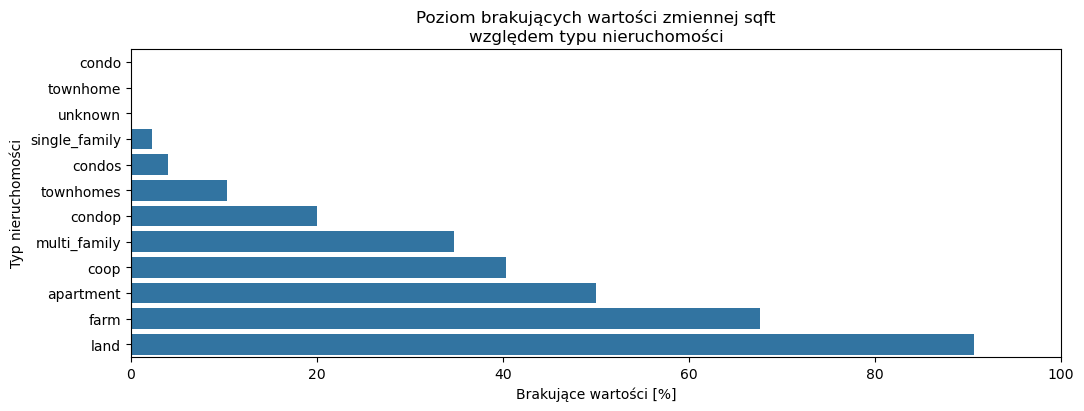

In [5]:
# ============================================================
# Brakujące wartości względem typu nieruchomości
# ============================================================

missing_by_type = (
    df_model
    .groupby("type")["sqft"]
    .apply(lambda x: x.isnull().mean() * 100)
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 4))

sns.barplot(
    x=missing_by_type.values,
    y=missing_by_type.index
)

plt.title(
    "Poziom brakujących wartości zmiennej sqft\n"
    "względem typu nieruchomości"
)

plt.xlabel("Brakujące wartości [%]")
plt.ylabel("Typ nieruchomości")

plt.xlim(0, 100)

plt.show()

In [6]:
# ============================================================
# Podsumowanie brakujących wartości względem typu nieruchomości
# ============================================================

type_summary = pd.DataFrame({
    "Udział w danych [%]": (
        df_model["type"]
        .value_counts(normalize=True) * 100
    ),

    "Brakujące sqft [%]": (
        df_model
        .groupby("type")["sqft"]
        .apply(lambda x: x.isnull().mean() * 100)
    ),

    "Liczba obserwacji": (
        df_model["type"]
        .value_counts()
    )
})

type_summary = (
    type_summary
    .round(2)
    .sort_values(
        by="Udział w danych [%]",
        ascending=False
    )
)

type_summary

,Udział w danych [%],Brakujące sqft [%],Liczba obserwacji
type,,,
single_family,61.54,2.24,5091
condos,11.45,4.01,947
multi_family,11.33,34.79,937
coop,9.36,40.31,774
land,3.61,90.64,299
townhomes,1.99,10.30,165
farm,0.41,67.65,34
condop,0.12,20.00,10
apartment,0.07,50.00,6


In [7]:
# ============================================================
# Ujednolicenie nazw typów nieruchomości
# ============================================================

df_model["type"] = df_model["type"].replace({
    "townhome": "townhomes",
    "condo": "condos"
})

In [8]:
# ============================================================
# Podgląd rekordów typu 'unknown'
# ============================================================

unknown_properties = df_model[
    df_model["type"] == "unknown"
]

unknown_properties.head()

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
452,unknown,NaN,The Birch is a well-crafted townhouse that ble...,865000.0,1998.0,2.0,2.0,NaN,2.0,2.0,1.0


In [9]:
# ============================================================
# Korekta typu nieruchomości dla rekordu 'unknown'
# ============================================================

df_model.loc[
    df_model["type"] == "unknown",
    "type"
] = "townhomes"

In [10]:
# ============================================================
# Wybór danych dla konkretnych typów nieruchomości
# ============================================================

residential_types = [
    "single_family",
    "condos",
    "townhomes",
    "coop",
    "condop",
    "apartment",
    "multi_family"
]

df_model = df_model[
    df_model["type"].isin(residential_types)
].copy()

print(df_model.shape)

(7940, 11)


In [11]:
# ============================================================
# Korelacja po filtrowaniu typów nieruchomości
# ============================================================

filtered_corr = df_model[
    ["listPrice", "sqft"]
].corr().round(3)

filtered_corr

,listPrice,sqft
listPrice,1.00,0.49
sqft,0.49,1.00


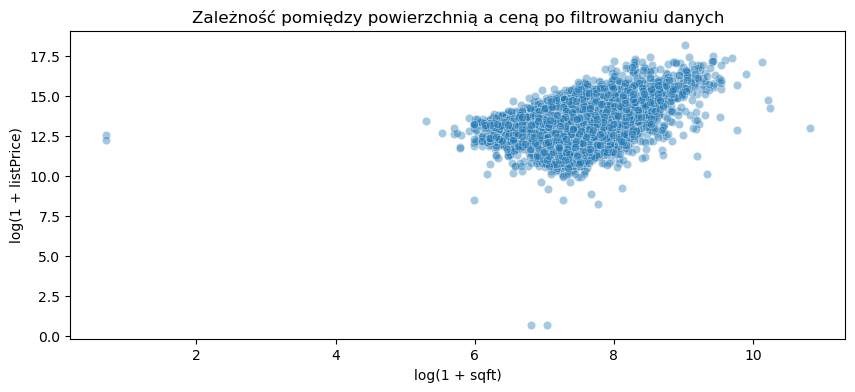

In [12]:
# ============================================================
# Rozkład zależności po filtrowaniu danych
# ============================================================

plt.figure(figsize=(10, 4))

sns.scatterplot(
    data=df_model,
    x=np.log1p(df_model["sqft"]),
    y=np.log1p(df_model["listPrice"]),
    alpha=0.4
)

plt.title(
    "Zależność pomiędzy powierzchnią "
    "a ceną po filtrowaniu danych"
)

plt.xlabel("log(1 + sqft)")
plt.ylabel("log(1 + listPrice)")

plt.show()

## 6.2. Ograniczenie wpływu wartości odstających i transformacja zmiennych numerycznych

W tej części przeprowadzono transformację wybranych zmiennych numerycznych w celu ograniczenia wpływu wartości odstających oraz poprawy rozkładów danych przed dalszym etapem modelowania predykcyjnego.

In [13]:
# ============================================================
# Transformacja zmiennych numerycznych
# ============================================================

df_model["log_listPrice"] = np.log1p(df_model["listPrice"])
df_model["log_sqft"] = np.log1p(df_model["sqft"])

In [14]:
# ============================================================
# Korelacja po transformacji logarytmicznej
# ============================================================

log_corr = df_model[
    ["log_listPrice", "log_sqft"]
].corr().round(3)

log_corr

,log_listPrice,log_sqft
log_listPrice,1.000,0.443
log_sqft,0.443,1.000


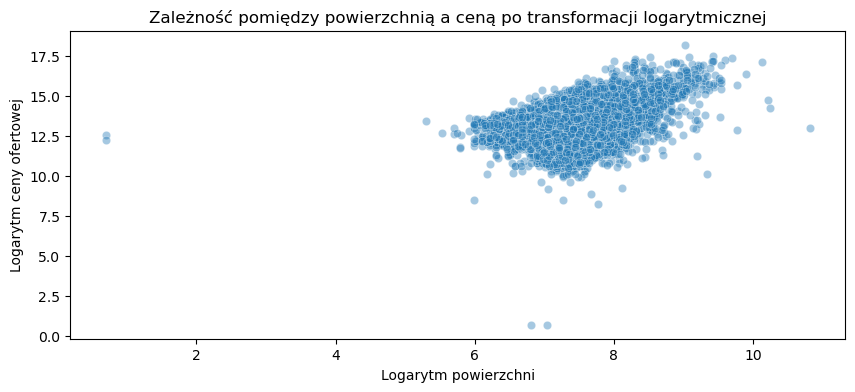

In [15]:
# ============================================================
# Zależność ceny od powierzchni
# po transformacji logarytmicznej
# ============================================================

plt.figure(figsize=(10, 4))

sns.scatterplot(
    data=df_model,
    x="log_sqft",
    y="log_listPrice",
    alpha=0.4
)

plt.title(
    "Zależność pomiędzy powierzchnią "
    "a ceną po transformacji logarytmicznej"
)

plt.xlabel("Logarytm powierzchni")
plt.ylabel("Logarytm ceny ofertowej")

plt.show()

## 6.3. Przygotowanie danych tekstowych do modelowania NLP

W kolejnym etapie przygotowano dane tekstowe do dalszego wykorzystania w modelach uczenia maszynowego. Proces obejmował końcowe czyszczenie tekstu oraz transformację opisów ofert nieruchomości do postaci numerycznej z wykorzystaniem metody TF-IDF.

In [16]:
# ============================================================
# Przygotowanie danych tekstowych do modelowania NLP
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [17]:
# ============================================================
# Czyszczenie tekstu
# ============================================================

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df_model["clean_text"] = df_model["text"].apply(clean_text)

In [18]:
# ============================================================
# Weryfikacja przygotowanego tekstu
# ============================================================

df_model[["text", "clean_text"]].head()

,text,clean_text
0,No description provided.,no description provided
1,Shortsale.,shortsale
2,Discover an exceptional investment opportunity...,discover an exceptional investment opportunity...
3,Classic Cape Cod with 4 bedrooms and 2 full ba...,classic cape cod with bedrooms and full baths ...
4,"Spacious 4-bedroom, 2.5-bath two-story home of...",spacious bedroom bath two story home offering ...


In [19]:
# ============================================================
# Lista stopwords używana przez scikit-learn
# ============================================================

english_stopwords = sorted(list(ENGLISH_STOP_WORDS))

print("Liczba stopwords:", len(english_stopwords))

english_stopwords[:100]

Liczba stopwords: 318


['a',
 'about',
 'above',
 'across',
 'after',
 'afterwards',
 'again',
 'against',
 'all',
 'almost',
 'alone',
 'along',
 'already',
 'also',
 'although',
 'always',
 'am',
 'among',
 'amongst',
 'amoungst',
 'amount',
 'an',
 'and',
 'another',
 'any',
 'anyhow',
 'anyone',
 'anything',
 'anyway',
 'anywhere',
 'are',
 'around',
 'as',
 'at',
 'back',
 'be',
 'became',
 'because',
 'become',
 'becomes',
 'becoming',
 'been',
 'before',
 'beforehand',
 'behind',
 'being',
 'below',
 'beside',
 'besides',
 'between',
 'beyond',
 'bill',
 'both',
 'bottom',
 'but',
 'by',
 'call',
 'can',
 'cannot',
 'cant',
 'co',
 'con',
 'could',
 'couldnt',
 'cry',
 'de',
 'describe',
 'detail',
 'do',
 'done',
 'down',
 'due',
 'during',
 'each',
 'eg',
 'eight',
 'either',
 'eleven',
 'else',
 'elsewhere',
 'empty',
 'enough',
 'etc',
 'even',
 'ever',
 'every',
 'everyone',
 'everything',
 'everywhere',
 'except',
 'few',
 'fifteen',
 'fifty',
 'fill',
 'find',
 'fire',
 'first',
 'five',
 'for'

In [20]:
# ============================================================
# Przygotowanie rozszerzenia listy słów do wykluczenia
# ============================================================

custom_stopwords = {
    "home",
    "room",
    "rooms",
    "property",
    "properties",
    "house",
    "living",
    "bedroom",
    "bedrooms",
    "bath",
    "baths",
    "bathroom",
    "bathrooms",
    "kitchen",
    "floor",
    "floors",
    "space",
    "offers",
    "offering",
    "features",
    "located",
    "area"
}

stop_words = list(
    ENGLISH_STOP_WORDS.union(custom_stopwords)
)

print("Liczba wszystkich stopwords:", len(stop_words))

Liczba wszystkich stopwords: 340


In [21]:
# ============================================================
# Przygotowanie reprezentacji tekstu metodą TF-IDF
# ============================================================

tfidf_vectorizer = TfidfVectorizer(
    stop_words=stop_words,
    max_features=1000,
    min_df=5,
    ngram_range=(1, 3)
)


In [22]:
# ============================================================
# Przygotowanie cech numerycznych i zmiennej docelowej
# ============================================================

numeric_features = [
    "log_sqft",
    "beds",
    "baths"
]

X_numeric = df_model[numeric_features]
y = df_model["log_listPrice"]

In [23]:
# ============================================================
# Podział danych na zbiór treningowy i testowy
# ============================================================

train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42
)

print("train_df:", train_df.shape)
print("test_df:", test_df.shape)

train_df: (6352, 14)
test_df: (1588, 14)


In [24]:
# ============================================================
# Przygotowanie TF-IDF
# ============================================================

X_train_tfidf = tfidf_vectorizer.fit_transform(
    train_df["clean_text"]
)

X_test_tfidf = tfidf_vectorizer.transform(
    test_df["clean_text"]
)

print("X_train_tfidf:", X_train_tfidf.shape)
print("X_test_tfidf:", X_test_tfidf.shape)

X_train_tfidf: (6352, 1000)
X_test_tfidf: (1588, 1000)


In [25]:
# ============================================================
# Podgląd przykładowych cech tekstowych
# ============================================================

tfidf_features = pd.DataFrame({
    "feature": tfidf_vectorizer.get_feature_names_out()
})

tfidf_features.head(30)

,feature
0,abundance
1,abundant
2,abundant natural
3,abundant natural light
4,ac
5,access
6,accessible
7,acre
8,acre lot
9,acres


## 6.4. Przygotowanie końcowego zbioru danych do modelowania

W ostatnim etapie przygotowania danych utworzono końcowy zbiór danych wykorzystywany w procesie modelowania predykcyjnego. Połączono przygotowane zmienne numeryczne opisujące nieruchomości, obejmujące logarytm powierzchni nieruchomości (`log_sqft`), liczbę sypialni (`beds`) oraz liczbę łazienek (`baths`), wraz z cechami tekstowymi uzyskanymi z transformacji TF-IDF.

W celu zachowania poprawności metodologicznej dane zostały najpierw podzielone na zbiór treningowy oraz testowy. Następnie transformacja TF-IDF została dopasowana wyłącznie na zbiorze treningowym, po czym wykorzystano ją do transformacji danych testowych. Pozwoliło to uniknąć zjawiska data leakage oraz zapewniło bardziej wiarygodną ocenę jakości modeli predykcyjnych.

In [26]:
# ============================================================
# Przygotowanie danych numerycznych
# ============================================================

from sklearn.impute import SimpleImputer

numeric_features = [
    "log_sqft",
    "beds",
    "baths"
]

numeric_imputer = SimpleImputer(
    strategy="median"
)

X_train_numeric = numeric_imputer.fit_transform(
    train_df[numeric_features]
)

X_test_numeric = numeric_imputer.transform(
    test_df[numeric_features]
)

print("X_train_numeric:", X_train_numeric.shape)
print("X_test_numeric:", X_test_numeric.shape)

X_train_numeric: (6352, 3)
X_test_numeric: (1588, 3)


In [27]:
# ============================================================
# Przygotowanie zmiennej docelowej
# ============================================================

y_train = train_df["log_listPrice"]

y_test = test_df["log_listPrice"]

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

y_train: (6352,)
y_test: (1588,)


In [28]:
# ============================================================
# Połączenie danych numerycznych i TF-IDF
# ============================================================

from scipy.sparse import hstack

X_train_full = hstack([
    X_train_numeric,
    X_train_tfidf
])

X_test_full = hstack([
    X_test_numeric,
    X_test_tfidf
])

print("X_train_full:", X_train_full.shape)
print("X_test_full:", X_test_full.shape)

X_train_full: (6352, 1003)
X_test_full: (1588, 1003)


In [29]:
# ============================================================
# Weryfikacja końcowych zbiorów danych
# ============================================================

print("X_train_full:", X_train_full.shape)
print("X_test_full:", X_test_full.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train_full: (6352, 1003)
X_test_full: (1588, 1003)
y_train: (6352,)
y_test: (1588,)


In [30]:
# ============================================================
# Zapis macierzy cech TF-IDF po podziale train/test
# ============================================================

save_npz(
    "X_train_tfidf.npz",
    X_train_tfidf
)

save_npz(
    "X_test_tfidf.npz",
    X_test_tfidf
)

In [31]:
# ============================================================
# Zapis końcowych zbiorów treningowych i testowych
# ============================================================

save_npz("X_train_full.npz", X_train_full)
save_npz("X_test_full.npz", X_test_full)

In [32]:
# ============================================================
# Zapis zmiennych docelowych
# ============================================================

y_train.to_csv(
    "y_train.csv",
    index=False
)

y_test.to_csv(
    "y_test.csv",
    index=False
)

In [33]:
# ============================================================
# Zapis vectorizera TF-IDF
# ============================================================

joblib.dump(
    tfidf_vectorizer,
    "tfidf_vectorizer.pkl"
)

['tfidf_vectorizer.pkl']

In [34]:
# ============================================================
# Zapis imputera danych numerycznych
# ============================================================

joblib.dump(
    numeric_imputer,
    "numeric_imputer.pkl"
)

['numeric_imputer.pkl']

In [35]:
# ============================================================
# Zapis pełnego dataframe po preprocessingu
# ============================================================

df_model.to_csv(
    "df_model.csv",
    index=False
)

In [36]:
# ============================================================
# Zapis zbiorów train/test po podziale danych
# ============================================================

train_df.to_csv(
    "train_df.csv",
    index=False
)

test_df.to_csv(
    "test_df.csv",
    index=False
)